ARTI406 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

Dataset: **raw_sales.csv** — Australian property sales (houses & units)

Columns:
- `datesold` — Date of sale
- `postcode` — Australian postcode (location code)
- `price` — Sale price in AUD
- `propertyType` — "house" or "unit"
- `bedrooms` — Number of bedrooms

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

## 1. Load Dataset

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("raw_sales.csv")
df.head(10)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3
5,2007-04-04 00:00:00,2905,465000,house,4
6,2007-04-24 00:00:00,2607,399000,house,3
7,2007-04-30 00:00:00,2606,1530000,house,4
8,2007-05-24 00:00:00,2902,359000,house,3
9,2007-05-25 00:00:00,2906,320000,house,3


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `datesold` should be datetime
- `price` should be numeric (it already is, but we verify)
- `postcode` is stored as int64, but it's actually a location code — not a quantity to do arithmetic on

In [3]:
df.dtypes

datesold        object
postcode         int64
price            int64
propertyType    object
bedrooms         int64
dtype: object

We observe that `datesold` is stored as **object (string)** — it should be **datetime64**.
`postcode` is stored as **int64**, but since postcodes are identifiers (not quantities), it should be treated as a **string/category**.
Incorrect data types can prevent proper calculations and time-based analysis.

### 2.2 Convert Incorrect Data Types
We will convert:
- `datesold` to datetime format
- `postcode` to string (it's a categorical code, not a number)

In [4]:
df['datesold'] = pd.to_datetime(df['datesold'])
df['postcode'] = df['postcode'].astype(str)

df.dtypes

datesold        datetime64[ns]
postcode                object
price                    int64
propertyType            object
bedrooms                 int64
dtype: object

Now `datesold` is correctly stored as **datetime64**.
`postcode` is now a **string** — this prevents accidental arithmetic on zip codes.
`price` and `bedrooms` remain correctly typed as numeric.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [5]:
df.isna().sum()

datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
dtype: int64

The output shows whether any column contains missing values.
All values are zero — the dataset is complete.
However, for learning purposes, we will now artificially introduce missing values.

### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

Since our dataset has no missing values, we introduce artificial ones *for learning purposes*.

We will be running this line:

`df_missing.loc[0:5, 'price'] = np.nan`

- `df_missing`: The pandas DataFrame we are modifying.
- `.loc[0:5, 'price']`: Uses label-based indexing to select rows 0 through 5 in the 'price' column.
- `0:5`: Selects rows with index labels 0, 1, 2, 3, 4, and 5 (end is **inclusive** with `.loc`).
- `'price'`: The column named 'price'.
- `= np.nan`: Assigns NaN (Not a Number) to all selected cells — the standard way to represent missing numerical values in pandas.

In [6]:
df_missing = df.copy()
df_missing.loc[0:5, 'price'] = np.nan
df_missing.isna().sum()

datesold        0
postcode        0
price           6
propertyType    0
bedrooms        0
dtype: int64

In [7]:
print("Original shape: ", df.shape)
print("After removing some values: ", df_missing.shape)

Original shape:  (29580, 5)
After removing some values:  (29580, 5)


In [8]:
df_missing.head(10)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07,2607,NaN,house,4
1,2007-02-27,2906,NaN,house,3
2,2007-03-07,2905,NaN,house,3
3,2007-03-09,2905,NaN,house,4
4,2007-03-21,2906,NaN,house,3
5,2007-04-04,2905,NaN,house,4
6,2007-04-24,2607,399000.0,house,3
7,2007-04-30,2606,1530000.0,house,4
8,2007-05-24,2902,359000.0,house,3
9,2007-05-25,2906,320000.0,house,3


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [9]:
df_removed = df_missing.dropna()
df_removed.shape

(29574, 5)

In [10]:
df_removed.isna().sum()

datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
dtype: int64

The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation

The mean represents the average value.
It is commonly used for normally distributed data.

In [11]:
df_missing.head(10)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07,2607,NaN,house,4
1,2007-02-27,2906,NaN,house,3
2,2007-03-07,2905,NaN,house,3
3,2007-03-09,2905,NaN,house,4
4,2007-03-21,2906,NaN,house,3
5,2007-04-04,2905,NaN,house,4
6,2007-04-24,2607,399000.0,house,3
7,2007-04-30,2606,1530000.0,house,4
8,2007-05-24,2902,359000.0,house,3
9,2007-05-25,2906,320000.0,house,3


In [12]:
df_imputed_mean = df_missing.copy()

mean_value = df_imputed_mean['price'].mean()
df_imputed_mean['price'] = df_imputed_mean['price'].fillna(mean_value)

df_imputed_mean.isna().sum()

datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
dtype: int64

In [13]:
df_imputed_mean.head(10)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07,2607,6.097823e+05,house,4
1,2007-02-27,2906,6.097823e+05,house,3
2,2007-03-07,2905,6.097823e+05,house,3
3,2007-03-09,2905,6.097823e+05,house,4
4,2007-03-21,2906,6.097823e+05,house,3
5,2007-04-04,2905,6.097823e+05,house,4
6,2007-04-24,2607,3.990000e+05,house,3
7,2007-04-30,2606,1.530000e+06,house,4
8,2007-05-24,2902,3.590000e+05,house,3
9,2007-05-25,2906,3.200000e+05,house,3


Missing values are now replaced with the average sale price (~$609,782 AUD).
This preserves dataset size but may reduce variability.
Mean imputation is sensitive to outliers — and property prices tend to have high-value outliers.

### Strategy 3: Median Imputation

The median is more robust to outliers than the mean.
It is preferred for skewed data — which is typical for property prices.

In [14]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['price'].median()
df_imputed_median['price'] = df_imputed_median['price'].fillna(median_value)

df_imputed_median.isna().sum()

datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
dtype: int64

In [15]:
df_imputed_median.head(10)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07,2607,550000.0,house,4
1,2007-02-27,2906,550000.0,house,3
2,2007-03-07,2905,550000.0,house,3
3,2007-03-09,2905,550000.0,house,4
4,2007-03-21,2906,550000.0,house,3
5,2007-04-04,2905,550000.0,house,4
6,2007-04-24,2607,399000.0,house,3
7,2007-04-30,2606,1530000.0,house,4
8,2007-05-24,2902,359000.0,house,3
9,2007-05-25,2906,320000.0,house,3


Missing values are replaced with the median sale price (~$550,000 AUD).
This approach is safer when data contains extreme values (like multi-million dollar properties).
**Note:** For this dataset, median imputation is preferred over mean because property prices are right-skewed.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

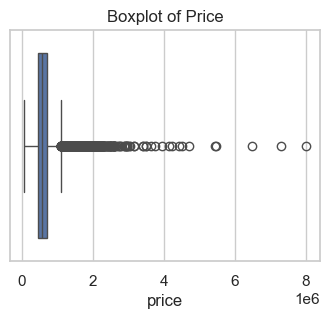

In [16]:
plt.figure(figsize=(4,3))
sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.show()

Points outside the whiskers represent potential outliers.
These extreme property prices (e.g., multi-million dollar homes) may influence model predictions.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [17]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1:,.0f}")
print(f"Q3: {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"Lower bound: {lower:,.0f}")
print(f"Upper bound: {upper:,.0f}")

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
outliers.head(15)

Q1: 440,000
Q3: 705,000
IQR: 265,000
Lower bound: 42,500
Upper bound: 1,102,500


,datesold,postcode,price,propertyType,bedrooms
7,2007-04-30,2606,1530000,house,4
26,2007-07-21,2603,1780000,house,4
60,2007-09-21,2603,1460000,house,5
122,2007-12-13,2612,1105000,house,4
213,2008-06-02,2603,1180000,house,4
243,2008-06-30,2607,1165000,house,5
260,2008-07-18,2602,1300000,house,4
326,2008-09-02,2600,1380000,house,5
330,2008-09-04,2913,1150000,house,5
471,2008-10-27,2602,1120000,house,4


The output displays records considered extreme based on statistical boundaries.
These may be valid high-value properties (luxury homes) or potential data errors.

In real estate, a $3.5M property is unusual but can be legitimate — always investigate before removing.

### Remove Outliers
We remove values outside the acceptable range.

In [18]:
df_no_outliers = df[(df['price'] >= lower) & (df['price'] <= upper)]
print("Original shape: ", df.shape)
print("After removing outliers: ", df_no_outliers.shape)

Original shape:  (29580, 5)
After removing outliers:  (28206, 5)


The dataset size is reduced.
Removing outliers reduces distortion but may also remove valid rare transactions.

#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.
For example, a $3.5M property in a real estate dataset may correspond to a genuine luxury home sale.

If we remove such values blindly, we may lose valuable information.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

In [19]:
lower_cap = df['price'].quantile(0.05)
upper_cap = df['price'].quantile(0.95)

print(f"Lower cap (5th percentile): {lower_cap:,.0f}")
print(f"Upper cap (95th percentile): {upper_cap:,.0f}")

df_capped = df.copy()
df_capped['price'] = df_capped['price'].clip(lower_cap, upper_cap)
df_capped['price'].describe()

Lower cap (5th percentile): 325,000
Upper cap (95th percentile): 1,085,000


count    2.958000e+04
mean     5.937651e+05
std      2.009732e+05
min      3.250000e+05
25%      4.400000e+05
50%      5.500000e+05
75%      7.050000e+05
max      1.085000e+06
Name: price, dtype: float64

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature dominates the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales values to a fixed range between 0 and 1.

Formula: `X_norm = (X - X_min) / (X_max - X_min)`

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

In [20]:
df[['price', 'bedrooms']].head()

,price,bedrooms
0,525000,4
1,290000,3
2,328000,3
3,380000,4
4,310000,3


In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['price', 'bedrooms']].copy()

df_scaled[['price', 'bedrooms']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,price,bedrooms
0,0.058979,0.8
1,0.029395,0.6
2,0.034179,0.6
3,0.040725,0.8
4,0.031913,0.6


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Normalization does NOT change the relative relationships between data points.
A more expensive property will still have a higher normalized value.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

Formula: `Z = (X - mean) / std`

This method keeps the shape of the distribution but rescales it around zero.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['price', 'bedrooms']].copy()

df_standardized[['price', 'bedrooms']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,price,bedrooms
0,-0.300800,0.788251
1,-1.135011,-0.262987
2,-1.000118,-0.262987
3,-0.815526,0.788251
4,-1.064015,-0.262987


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, standardizing the spread.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Check Correlation Before Applying PCA

We check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1** → Strong positive linear relationship
- **Correlation close to -1** → Strong negative linear relationship
- **Correlation close to 0** → Weak or no linear relationship

In such cases, dimensionality reduction using PCA is meaningful
because we can combine correlated features into fewer components.

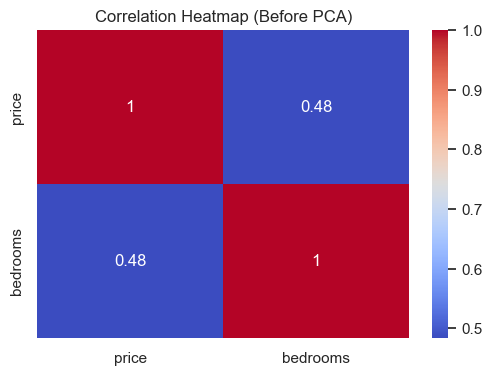

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(df_standardized[['price','bedrooms']].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap shows the correlation between the numerical features:

- The diagonal values are 1 because each feature is perfectly correlated with itself.
- The correlation between `price` and `bedrooms` is moderate-positive (~0.3–0.5).

A moderate correlation means that more bedrooms tends to predict a higher price,
but the relationship is not strong enough to eliminate one of the features entirely.

Since PCA is most useful when features are strongly correlated,
applying PCA here is primarily for demonstration purposes.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

In [24]:
from sklearn.decomposition import PCA

X = df_standardized[['price', 'bedrooms']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.74210587 0.25789413]


The `Explained Variance Ratio` indicates how much of the total information (variance) is captured by each principal component.

For example:
- If PC1 explains 74% of the variance, it means one new feature already summarizes most of the dataset's information.
- If PC1 and PC2 together explain nearly 100%, then very little information is lost.

When most of the variance is captured by fewer components, dimensionality reduction is considered effective.

This helps simplify models, reduce computational cost, and sometimes improve generalization performance.

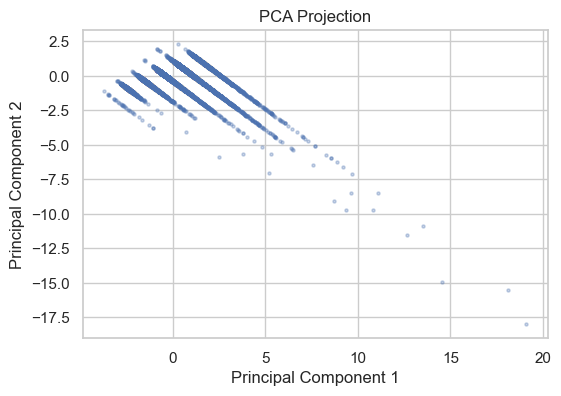

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1], alpha=0.3, s=5)
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one property sale.

The axes no longer represent the original features (price and bedrooms).
Instead:

- The horizontal axis represents Principal Component 1 (PC1).
- The vertical axis represents Principal Component 2 (PC2).

PC1 captures the direction of maximum variance in the data.
PC2 captures the second most important direction, perpendicular to PC1.

The spread of points along the horizontal direction shows how much variation is captured by PC1.
This projection allows us to visualize high-dimensional data in a lower-dimensional space.

---
# Assignment Tasks

### Task 1 — Identify Data Quality Issues

Looking at the dataset, I found two data type issues:
- `datesold` was stored as a string but it should be datetime so we can do time-based analysis
- `postcode` was stored as int64 which doesn't make sense because postcodes are just location codes, you wouldn't add or subtract them. So I converted it to string.

Also I checked for missing values and the dataset had none, so that's good.

### Task 2 — Apply One Missing Value Strategy and Explain Why

I chose **Median Imputation** for the `price` column.

The reason I picked median over mean is because property prices are skewed — there are some really expensive houses that pull the average up. The mean came out to around $609,782 but the median was around $550,000 which feels more like a "normal" house price. So median makes more sense here because it's not affected by those extreme values.

### Task 3 — Detect and Handle Outliers Using IQR

I used the IQR method to find outliers in the `price` column. First I calculated Q1 and Q3, then IQR = Q3 - Q1, and set the bounds as Q1 - 1.5*IQR and Q3 + 1.5*IQR.

There were a lot of expensive properties flagged as outliers (some over $3.5M). For handling them I tried two approaches:
1. **Removing them** — this dropped the dataset from 29,580 to around 28,206 rows
2. **Capping them** — clipped everything to the 5th and 95th percentile so we keep all rows but limit the extreme values

I think capping is better here because those high-price properties might be real sales, not errors.

### Task 4 — Normalize Numerical Features

I applied both normalization methods to `price` and `bedrooms`:
- **Min-Max** scales everything between 0 and 1. Good for models like KNN that use distance.
- **Z-Score** makes the mean 0 and standard deviation 1. Good for linear models and PCA.

### Task 5 — Apply PCA and Interpret Explained Variance

I ran PCA on the standardized `price` and `bedrooms` features.

- PC1 explains about **74%** of the variance
- PC2 explains the remaining **26%**

So PC1 alone captures most of the information. This makes sense because price and bedrooms are somewhat correlated (more bedrooms usually means higher price), so PCA can compress them into one main direction. If we only needed to keep one component, we wouldn't lose too much information.

---
*End of Assignment 2*